# NIRC2Pol-DPP Basic Tutorial

This tutorial walks through a complete reduction of Keck/NIRC2 polarimetry
(NIRC2-Pol) data, from raw FITS frames to Stokes cubes and radial Stokes
images, using real commissioning data (AB Aurigae circumstellar disk, 2025-12-08 UTC, L'; Lewis et al. 2026b in prep).

**What the pipeline does**, in order:

```
raw frames ──► sort by type ──► master darks/flats ──► reduce science frames
   (dark subtraction, flat fielding, bad-pixel cleanup)
      ──► sky subtraction ──► HWP cycle matching ──► beam splitting
      ──► image registration ──► double differencing ──► Stokes cubes
      ──► other optional outputs including median Stokes cube, PI / AoLP / DoLP, radial Stokes
```

**How the code is organized** (each layer only talks to the one below it):

| layer | package | contents |
|---|---|---|
| orchestration | `pipeline.py` | chain steps into a "recipe" (optional) |
| polarimetry | `polarimetry/` | double differencing, Stokes cubes, radial Stokes, Mueller interface |
| reduction | `reduction/` | masters, calibration, sky subtraction, registration |
| instrument | `instruments/` | everything NIRC2-specific, behind the `PolarimetryData` interface |
| helpers | `utils/` | `Frame` (image + header), FITS I/O, image operations |

You can run the whole chain, or any single
step, from a script or notebook. The design of the DPP is detailed in an SPIE proceeding ([Lewis et al. 2026a](https://arxiv.org/abs/2608.14864)).

## 0. Setup

Requirements: Python ≥ 3.11 with `numpy`, `scipy`, `astropy`, and `pyklip`
(used for image rotation). 

In [1]:
import sys, os, glob
sys.path.insert(0, os.path.abspath(".."))  # repo root, if running from examples/

import numpy as np
import matplotlib.pyplot as plt

# the four layers
from utils import Frame, load_frames, crop
from reduction import (fit_beam_geometry, make_master_darks,
                       make_master_flats, make_master_masks,
                       reduce_frame)
from instruments.nirc2 import NIRC2PolarimetryData
from polarimetry import (build_stokes_cubes, median_stokes_cube,
                         polarization_products, radial_stokes)

## 1. The data model: `Frame` and the instrument object

The pipeline passes around `Frame` objects — just image data plus the FITS
header, with dict-style keyword access. The below code block is not needed when you write a reduction script -- it's just here to show you how the `Frame` objects work!

In [2]:
# The tutorial dataset ships with the repository: 14 frames of AB Aur,
# 2025-12-08 UT, L' + Wollaston. See examples/tutorial_data/README.md for
# what is in it and why. 
DATA = next(p for p in ("examples/tutorial_data",       # from the repo root
                        "tutorial_data",                 # from examples/
                        "../examples/tutorial_data")     # from anywhere else
            if os.path.isdir(p))

frame = Frame.load(f"{DATA}/raw/n0932.fits.gz")   # an AB Aur science frame
print(frame)
print("shape:", frame.shape)
print("OBJECT:", frame["OBJECT"], "| FILTER:", frame["FILTER"],
      "| ITIME:", frame["ITIME"], "| HWP angle (PCUPR):", frame.get("PCUPR"))

Frame(n0932.fits, shape=(1024, 1024))
shape: (1024, 1024)
OBJECT: AB Aur_hwp_0.0 | FILTER: Lp + Wollaston | ITIME: 0.45 | HWP angle (PCUPR): -0.002


Everything NIRC2-specific — header keywords, detector constants, beam
geometry, the polarimetric rotation model — lives in one object,
`NIRC2PolarimetryData`. You can create a subclass for your specific dataset that takes `NIRC2PolarimetryData` as an object, and then allows you to specify different settings and attributes for that dataset.

For on-sky data, a user must also specify how the sky/thermal background is removed. Which method is recommended depends on the band:
L' generally requires sky flats and/or dithers (but is sometimes done by just taking the mean of the background in the science frames), JHK is often done with typical aperture photometry methods (i.e. an annulus around the source).

In [3]:
class LpPolData(NIRC2PolarimetryData):
    """12-07 NIRC2 pol data for L': mean-box background (this run was not dithered)."""

    background_method = "mean_box"        # "mean_box" | "annulus" | "dither" | None
    background_box = (25, 350, 50, 400)   # (ylow, yhigh, xlow, xhigh)
    # beam geometry is measured from the data further down, not set here

instrument = LpPolData()

##Examples of different instrument object attributes
print("background:", instrument.describe_background())
print("modulator keyword:", instrument.modulator_keyword)
print("HWP critical angles:", instrument.critical_angles)
print("gain [e-/ADU]:", instrument.gain(frame))
print("saturation [ADU]:", instrument.saturation_limit(frame))

background: mean_box(25, 350, 50, 400)
modulator keyword: PCUPR
HWP critical angles: (0.0, 45.0, 22.5, 67.5)
gain [e-/ADU]: 8.0
saturation [ADU]: 4500.0


## 2. Sorting raw frames

`instrument.sort_frames` classifies raw files from their headers alone similar to what's done with the Keck Observatory Archive (KOA):

- shutter closed → **dark**

- telescope at the dome-flat position, AO loops open, counts above threshold → **dome flat** (the lamp is how one is recognized, not a separate kind)

- OBJECT containing "sky"/"twi" → **sky flat**

- everything else → **science**

*This tutorial only uses a small subset of the full science dataset for AB Aur to prevent overloading the repo with data storage. Results in this notebook are **not** indicative of NIRC2-Pol's full capabilities, and are instead intended only to demonstrate the pipeline workflow.*

In [4]:
# The bundle is already the subset a tutorial needs -- sky flats, darks and two HWP cycles of AB Aur
raw_files = sorted(glob.glob(f"{DATA}/raw/*.fits*"))

sorted_files = instrument.sort_frames(raw_files)
for kind, files in sorted_files.items():
    print(f"{kind:14s} {len(files)} frames")

sci            8 frames
flats_dome     0 frames
flats_sky      4 frames
darks          3 frames


## 3. Master darks and flats

Frames are grouped by exposure settings (`ITIME, COADDS,
SAMPMODE, READS`, plus `FILTER` for flats); each group is median-combined,
sigma-clipped, cleaned with the detector bad-pixel mask, and stamped with
bookkeeping keywords (`NFRAMES`, `MAMEDIAN`, `FLATTYPE`, ...).

Flats are dark-subtracted and normalized to a median of 1. Dark subtraction
is mandatory: `make_master_flats` refuses to build one unless you pass
`allow_flat_without_dark=True`.

**The kind of flat is a requirement, not a preference.** L' must use
sky flats and JHK must use dome flats. Reducing with the wrong kind gives a wrong answer that
still looks plausible, so `find_closest_flat` raises rather than
substituting. Pass `required_flat_type="SKY"` to override the band default,
or `allow_flat_type_mismatch=True` to proceed anyway (which records
`FLATMISM` in the header).

A flat has two **independent** properties. Its *kind* is where the light came
from — `DOME` (the dome screen) or `SKY` (twilight) — and that is what the
band requirement above is about. Whether it is *polarimetric* is a separate
question, and either kind can be: a polarimetric dome flat and a polarimetric
sky flat are both ordinary things to have. So one night can yield up to four
masters per filter. Within the kind the band requires, polarimetric flats are
preferred, falling back to non-polarimetric ones when there are none.

**Polarimetric is a property of the set, not of one frame**, and it depends on
where the HWP was (`PCUNAME`: `hwp_center` is in the beam, `home` and
`telescope` are out):

- **HWP out of the beam** → an ordinary flat. It sees the bare optics.
- **HWP in, complete cycle** — all four critical angles, each appearing the
  same number of times → a polarimetric flat. Combining the full set averages
  the flat source's own polarization away, which matters because twilight sky
  is strongly polarized. Equal weight is the point: an angle observed more
  often than the others tips the average toward it and the cancellation fails,
  so surplus frames at over-represented angles are set aside to leave the
  largest balanced set.
- **HWP in, incomplete cycle** → *neither*, and it is discarded with a
  warning. It cannot be a polarimetric flat, because the cycle does not close
  and the source's polarization stays in it — with 0, 45 and 67.5 the Q pair
  cancels while the lone U angle does not. It cannot be an ordinary flat
  either, because the HWP's transmission is baked in.

This bundle's four sky flats are one complete cycle, so they build a
polarimetric `SKY` master.

In [5]:
darks = load_frames(sorted_files["darks"])
master_darks, dark_masks = make_master_darks(darks, instrument=instrument)

master_flats, flat_masks = make_master_flats(
    load_frames(sorted_files["flats_dome"]),
    load_frames(sorted_files["flats_sky"]),
    master_darks,
    instrument=instrument,
)
master_masks = make_master_masks(dark_masks, flat_masks)

print(f"{len(master_darks)} master darks, {len(master_flats)} master flats")
for f in master_flats[:3]:
    print("  flat:", f["FILTER"], "| FLATTYPE", f["FLATTYPE"],
          "| polarimetric:", f.get("POLFLAT"), "| from", f["NFRAMES"], "frames")

1 master darks, 1 master flats
  flat: Lp + Wollaston | FLATTYPE SKY | polarimetric: True | from 4 frames


## 4. Reducing the science frames

`reduce_frame` applies, per frame:

1. find the best-matching dark (relaxing the match criteria step by step)
   and flat — the **filter must always match**, size is only preferred (a
   larger flat is trimmed to the frame), and exposure settings are ignored
   because the flat is normalized. Flat type is also enforced unless overridden (sky for L', dome for JHK)
2. `reduced = (raw − dark) / flat`
3. divide by COADDS. Not a units choice: the saturation check in the
   next step compares against a per-read limit, so this has to run first
4. replace bad pixels (detector mask + sigma-clip masks + NaNs) by local
   thin-plate-spline interpolation; saturated pixels get a wider "+"-shaped
   replacement
5. divide by ITIME, then multiply by the gain, giving electrons per
   second; record everything in header keywords (`DARKSUB`, `FLATDIV`,
   `DIVCOADD`, `DIVITIME`, `GAIN`, `BUNIT`, `RED-FN`). `BUNIT` states the
   resulting units, derived from which of these actually ran

This chain came from AIR.jl and reproduced its reduction of this same
night bit for bit. It no longer does: AIR.jl leaves `div_itime` off, so
its frames are counts per *coadd* where these are counts per *second*.
Everything else matches, and passing `div_itime=False` recovers the
original agreement. No polarization fraction depends on the choice --
the factor divides out of Q/I -- but absolute surface brightness does.

In [6]:
bad_pixel_mask = instrument.bad_pixel_mask()   # static NIRC2 mask
sci_frames = load_frames(sorted_files["sci"])
print(f"{len(sci_frames)} science frames")

reduced_frames = []
for f in sci_frames:
    r = reduce_frame(f, master_flats, master_darks, None, master_masks,
                     bad_pixel_mask=bad_pixel_mask,
                     required_flat_types=instrument.required_flat_types,
                     default_required_flat_type=(
                         instrument.default_required_flat_type),
                     gain=instrument.gain(f),
                     saturation_limit=instrument.saturation_limit(f))
    reduced_frames.append(r)

r = reduced_frames[0]
print(r["RED-FN"], "| dark subtracted:", r["DARKSUB"],
      "| flat divided:", r["FLATDIV"])

8 science frames


reduced_0932.fits | dark subtracted: True | flat divided: True


To save intermediate products, you can use
(`r.save(os.path.join(paths.reduced_folder, r["RED-FN"]))`) using the
standard folder layout from `ObslogPaths`. See `examples/process_polmode.py`
for the full script version.

**Sky subtraction** comes next when needed. Options in `reduction.sky`:
`subtract_annulus_background` (JHK, usually sufficient),
`subtract_dither_pairs` (L', rapidly varying thermal background),
`subtract_sky_frames` (dedicated master skies). This tutorial uses none of
the three: the `background_method = "mean_box"` set on `LpPolData` in
section 1 is applied per beam inside the Stokes builder, which calls
`instrument.subtract_background(instrument.split_beams(frame))`
(see `polarimetry/stokes.py`). For a mean-box or annulus background,
configure it on the instrument rather than subtracting from the frames
here.

## 5. HWP cycle matching

NIRC2-Pol modulates with the half-wave plate stepping through the four
critical angles **0°, 45°, 22.5°, 67.5°** (header keyword `PCUPR`).
`match_modulator_cycles` walks the frames in time order and groups them into
complete cycles, recording the mapping in each frame's `POLCYCLE` keyword.
Incomplete trailing groups are dropped with a warning.

### First: which frames does this reduction cover?

Everything so far ran on the whole night — darks, flats and reduced frames are
built for all of it, which is what you want, since they are reusable. From here
on the pipeline builds *science products*, and those should come from only the
frames you trust.

Two tools that are easy to confuse:

| | means | scope |
|---|---|---|
| **rejects** | this frame is *bad* — open AO loop, satellite trail | `<date>_rejects.toml`; applies to every run of the night and keeps the reason |
| **selection** | these are the frames *this run* covers | per reduction, set in the script |

`select_frames` takes a target name — matched ignoring case, spaces and
underscores, so `"AB_Aur"` finds a header reading `"AB Aur"` — and/or an
inclusive frame-number range read from the filenames, which is how an obslog
refers to a night. `nirc2.make_frametable` writes the table to look at while
deciding.

This matters beyond tidiness. `match_modulator_cycles` walks frames in time
order, so a pointing that ends mid-cycle can absorb the start of the next one.
It breaks a cycle when the target changes, but saying which frames you meant is
the reliable answer.

In [7]:
from utils import select_frames

# Every frame in this bundle is AB Aur, so this changes nothing here -- it is
# the shape of the call that matters. Criteria combine with AND, and None means
# "no constraint", so select_frames(frames) returns everything.
reduced_frames = select_frames(reduced_frames, target="AB_Aur")
print(f"{len(reduced_frames)} frames selected")

# by frame number instead (inclusive, read from the filename):
#   reduced_frames = select_frames(reduced_frames, frame_range=(932, 939))

# to mark a frame bad for every run of this night, with the reason:
#   from utils.paths import record_reject
#   record_reject(paths.rejects_file, "n0937.fits", "open AO loop")

8 frames selected


In [8]:
# Measure where the two beams sit, from these frames. The search starts
# from a seed in instruments/nirc2.ini and converges from ten rows away,
# so the seed only has to be roughly right. split_beams refuses until
# this has run, because a wrong geometry cannot be undone downstream.
instrument.top_row_start, instrument.beam_x_offset = fit_beam_geometry(
    instrument, reduced_frames)
print("beam geometry:", instrument.top_row_start,
      instrument.beam_x_offset)

cycles = instrument.match_modulator_cycles(reduced_frames)
print(f"{len(cycles)} complete HWP cycles")
print("cycle 0 HWP angles:",
      [round(instrument.modulator_angle(f), 1) for f in cycles[0]])

Measured beam_x_offset = 12.51 sits between pixels, so rounding either way leaves about half a pixel of beam misalignment. Compare both by reducing with each and seeing which gives less U_phi.


beam geometry: 504 13
2 complete HWP cycles
cycle 0 HWP angles: [-0.0, 45.0, 22.5, 67.5]


## 6. Stokes cubes: split, register, double-difference, rotate

`build_stokes_cubes` does the polarimetric core, per cycle:

1. **beam splitting** — `instrument.split_beams` cuts the two orthogonally
   polarized Wollaston beams (bottom = beam 0, top = beam 1, x-offset
   removed) → a registered `(2, ny, nx)` stack
2. **registration** — the star is located on the mean of the two beams and
   both are shifted together so it lands at the image center.
   `register_method` picks the algorithm, and the right choice depends on
   what the source looks like:

   | source | method |
   |---|---|
   | point source | `"smooth_peak"` (default) |
   | saturated core | `"min"` |
   | resolved body (planet, moon) | `"symmetry"`, `"centroid"`, `"silhouette"` |
   | behind a coronagraph | `"wings"` — masks the core, uses the PSF wings |
   | aligning to a reference | `"crosscorr"` with `template=` |
   | not detectable in one frame | `None` — do not register at all |

   Peak finding fails badly on a resolved body, on an occulted star, and on this
   tutorial's own data: AB Aur's L' core is saturated, so it reads low and
   leaves several rim maxima within a few percent of each other.
   Because AB Aur here is saturated, we use `"min"` in this tutorial. Pass
   `search_center` / `search_radius` to confine the search when a brighter
   neighbour or a detector artefact sits in the field. Any callable
   returning `(cy, cx)` also works.
3. **double differencing** (SPIE Eqs. 1–2, note the ½ factors):
   `Q = ½[(top−bot)(0°) − (top−bot)(45°)]`,
   `U = ½[(top−bot)(22.5°) − (top−bot)(67.5°)]`,
   `I = ¼ Σ (top+bot)`
4. **rotation to sky** (Eqs. 3–5): `θ_rot = −2·PARANG + 2·EL + 2·ROTPDEST
   + 4·θ_off`, then `Q′ = Q cosθ + U sinθ`, `U′ = −Q sinθ + U cosθ`
5. **derotation** to north-up east-left (pyklip rotation)

The **fast axis offset θ_off** has to be determined **on sky** and passed
in explicitly. Leaving θ_off at its 0 deg default does not rotate Q/U into
the sky frame correctly, and the pipeline warns once if you do.

In [9]:
# theta_off has to be measured on sky and set explicitly
theta_off = -13   # [deg] -- REPLACE with a value measured on sky. this is the value determined for this epoch of AB Aur

# register_method="min" because this core is saturated
stokes_cubes = build_stokes_cubes(instrument, cycles,
                                  fast_axis_offset=theta_off,
                                  register_method="min")
print("per-cycle Stokes cubes:", stokes_cubes.shape,
      "  # (ncycles, [I,Q,U], ny, nx)")


per-cycle Stokes cubes: (2, 3, 450, 1011)   # (ncycles, [I,Q,U], ny, nx)


## 7. Final products

Median-combine the per-cycle cubes, then derive polarized intensity (PI),
angle and degree of linear polarization (AoLP, DoLP), and the radial Stokes
images. With the pipeline's sign convention (SPIE Eqs. 6–7) a
tangentially-polarized disk is **positive in Q_phi** while U_phi contains
noise — verified on this AB Aur dataset.

/home/blewis/NIRC2Pol-DPP/polarimetry/stokes.py:397: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian(np.asarray(stokes_cubes), axis=0)


Q_phi mean in annulus: 63.48
U_phi std  in annulus: 39.07


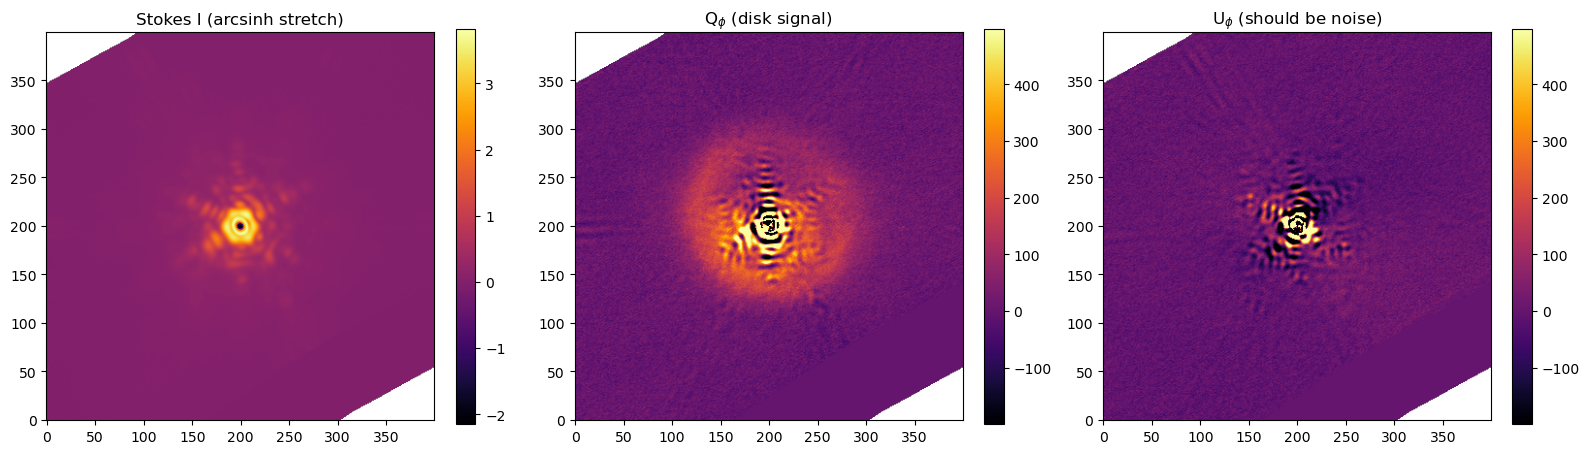

In [10]:
med = median_stokes_cube(stokes_cubes)          # (3, ny, nx): I, Q, U

ny, nx = med.shape[1:]
star = ((ny - 1) / 2, (nx - 1) / 2)
I, Q, U = (crop(p, (400, 400), center=star)[0] for p in med)

pi, aolp, dolp = polarization_products(np.stack([I, Q, U]))
q_phi, u_phi = radial_stokes(Q, U)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
scale = float(np.nanstd(q_phi))          # common stretch for Q_phi and U_phi

im = axes[0].imshow(np.arcsinh(I / np.nanstd(I)), origin="lower", cmap="inferno")
axes[0].set_title("Stokes I (arcsinh stretch)")
fig.colorbar(im, ax=axes[0], fraction=0.046)

for ax, img, title in [(axes[1], q_phi, "Q$_\\phi$ (disk signal)"),
                       (axes[2], u_phi, "U$_\\phi$ (should be noise)")]:
    im = ax.imshow(img, origin="lower", cmap="inferno",
                   vmin=-scale, vmax=2.5 * scale)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig("tutorial_products.png", dpi=100)

# average disk signal in an annulus around the star (star is at the center)
yy, xx = np.mgrid[:400, :400]
radius = np.hypot(yy - 199.5, xx - 199.5)
annulus = (radius > 25) & (radius < 150)
print("Q_phi mean in annulus:", round(float(np.nanmean(q_phi[annulus])), 2))
print("U_phi std  in annulus:", round(float(np.nanstd(u_phi[annulus])), 2))

Save the products. `ProductWriter` gives each one a descriptive name and
records how it was made, so a file can be audited later without the
script that produced it:

In [11]:
from polarimetry import ProductWriter
from utils.provenance import describe

header = cycles[0][0].header.copy()
header["THETAOFF"] = (theta_off, "fast axis offset [deg]")

# Let ProductWriter name and stamp each product. Saving by hand with
# Frame(...).save() inherits this header unchanged, so the median cube
# and the Q_phi image would carry identical provenance -- neither of
# them saying which one it is.
writer = ProductWriter("tutorial_output", target="AB_Aur")
writer.save_median_stokes(np.stack([I, Q, U]), header=header)
writer.save_derived_products(np.stack([I, Q, U]), header=header)

# every product can now account for itself
print(describe(Frame.load("tutorial_output/AB_Aur_Qphi.fits")))

NIRC2Pol-DPP 95de388+local processed 2026-08-21T02:35:49+00:00
  DPP dark/flat reduction: dark=n0984.fits, flat=n0902.fits, polflat=True, flat_checked=True, flat_mismatch=False, flat_substituted=False, flat_filter=Lp + Wollaston, gain=8, saturation=4500, div_coadds=True, div_itime=True, badpix=interpolation [2026-08-21T02:35:49Z]
  DPP stokes cube: instrument=NIRC2, nframes=4, beam_geometry=(504, 13), background=mean_box(25, 350, 50, 400), critical_angles=[0 4522.5 67.5], registration=min, fast_axis_offset=-13, instrumental_polarization=none, ip_frame_annulus=none, qu_rotation=-167.95,north_angle=213.177 [2026-08-21T02:35:51Z]
  DPP radial Stokes Q_phi: center=None [2026-08-21T02:35:52Z]


## 8. Instrumental polarization and the fast axis

Instrumental polarization is the I → Q/U crosstalk that leaks a fraction of
the total intensity into the polarized channels: an unpolarized source comes
out with `Q = ipq * I`, `U = ipu * I`. On NIRC2 it runs of order 1–2 %.

Two ways to measure it, because neither works everywhere. **`fit_ip_uphi`**
minimizes the U_phi residual and needs a bright, azimuthally polarized disk;
on AB Aur it gives ipq = −1.11 ± 0.44 %, reproducing the −1.2 % measured
previously by a different route. **`measure_ip_cycle`** instead uses an
annulus just outside the occulting mask, where the light is the star's own
(assumed unpolarized) PSF — the radii default to the coronagraph size, read
from `SLITNAME`.

```python
from polarimetry import fit_ip_uphi, mean_ip, measure_ip_cycle

ip = mean_ip([fit_ip_uphi(instrument, c, theta_off, mask_radius=22,
                          crop_size=400) for c in cycles])
print(ip.describe())          # the scatter across cycles is the error bar

cubes = build_stokes_cubes(instrument, cycles,
                           fast_axis_offset=theta_off, ip=ip)
```

The correction happens in the **instrument frame**, before Q/U are rotated to
sky — which is why it is an argument to the cube builder rather than
something you subtract from a finished product.

θ_off itself has to be measured on sky. An HWP ladder on an internal source
returns θ_off + χ/2, with χ the incident polarization angle in the
instrument frame, so those values carry an unknown error. A disk's light is
polarized tangentially, so a wrong θ_off shows up as the butterfly pattern
being rotated:

```python
from polarimetry import fit_fast_axis_on_sky, scan_fast_axis_offset
from polarimetry.fast_axis import prepare_cycles

res = fit_fast_axis_on_sky(instrument, cycles, r_inner=25, r_outer=150)
print(res.describe())

prepared = prepare_cycles(instrument, cycles)
offsets, scores = scan_fast_axis_offset(prepared, r_inner=25, r_outer=150)
```

On AB Aur these agree at −12.97° (offset alone), −12.85° (joint with IP) and
a scan minimum of −13.00°, against a retired lamp value of −8.18°.

Both assume an azimuthally polarized source. On an AGN, a merger or a star
field they return a confident number that means nothing.

`polarimetry/mueller.py` still holds `fit_empirical_cycle_correction`, the
older 16-parameter fit of beam shifts *and* IP together; prefer `fit_ip_uphi`
unless residual beam misalignment is the actual problem.


## 8b. Writing products, and reading their provenance

Section 7 used `ProductWriter` for two of the products. It writes the whole
set the same way — reduced frames, one Stokes cube per HWP cycle *and* a
stacked cube, the median Stokes cube, and PI / AoLP / DoLP / Q_phi /
U_phi — under a single output directory you set in one place:

```python
from polarimetry import ProductWriter

writer = ProductWriter("/path/to/output", target="AB_Aur")
writer.save_reduced(reduced_frames)
writer.save_stokes_cycles(stokes_cubes, cycles, header=header)
writer.save_median_stokes(median_cube, header=header)
writer.save_derived_products(median_cube, header=header)
```

Every product records how it was made, so a file can be audited months
later without the script that produced it:

```python
from utils.provenance import describe
print(describe(Frame.load("output/AB_Aur_median_stokes.fits")))
```

```
NIRC2Pol-DPP c71c0e9 processed 2026-07-29T07:15:56
  DPP dark/flat reduction: dark=n1013.fits, flat=n0024.fits, polflat=T
  DPP stokes cube: instrument=NIRC2, background=annulus(150, 220), ...
  DPP median-combined Stokes cube: ncycles=16
```

## 9. The pipeline orchestrator (optional)

For push-button reductions, chain the steps into a `Pipeline`: each step is
a function of the shared context dict, its result is stored under the step's
name, and every intermediate product stays inspectable afterwards.

```python
from pipeline import Pipeline

pipe = Pipeline({"instrument": instrument})
pipe.add_step("cycles", lambda ctx: ctx["instrument"].match_modulator_cycles(reduced_frames))
pipe.add_step("stokes", lambda ctx: build_stokes_cubes(
    ctx["instrument"], ctx["cycles"], fast_axis_offset=theta_off))
ctx = pipe.run()
ctx["stokes"].shape        # every product remains accessible
```

`pipe.run(from_step="stokes")` re-runs from a given step after you tweak a
parameter.

## 10. Conventions, gotchas, and troubleshooting

**Conventions**
- Data arrays are `data[y, x]`; coordinates are `(cy, cx)`, 0-based.
- Double differences carry the ½ factors (SPIE Eqs. 1–2). Reductions that
  omit them (e.g. the commissioning notebooks) are **2×** these values on
  that account, but they also skip the per-second division, which makes these values
  1/ITIME larger. The two pull opposite ways, leaving such a reduction at
  2 x ITIME of these -- for this dataset (ITIME = 0.45 s) that is 0.9x,
  slightly smaller rather than larger. `BUNIT` in the header
  says which units a given file is actually in.
- Q_phi = +Q cos2φ + U sin2φ (Eq. 6): tangential disk signal is positive.
- `rotate_image_center(img, a)` rotates clockwise in `origin="lower"`
  display (pyklip backend, sign-matched); derotation uses `−north_angle`.
- θ_off must be measured on sky and passed explicitly; there is no trusted
  automatic source, and the 0 deg default is not a calibration.

**Gotchas**
- *Saturated PSF cores*: at L' the core often reads low (a "donut"), and
  the default `smooth_peak` does **not** handle it — the rim maxima are
  near-equal, so it hops between them and the combined PSF comes out
  doubled. Use `register_method="min"`, which centres on the hole. Check
  by registering every frame and looking at the scatter of the centres:
  on this dataset `smooth_peak` spans 18 px and `"min"` spans 0.
- *Field-mask edges*: the Wollaston field mask produces strongly
  "polarized-looking" stripes at the beam edges — mask them in analysis.
- *Inner ~15 px after the empirical correction*: sub-pixel shifts of the
  bright core cause interpolation ringing there.
- *Known limitation*: at the calibrated θ_off, on-sky data show a residual
  ≈25° of unmodeled polarimetric rotation (elevated disk-region U_phi, seen
  on both AB Aur and HL Tau) — this awaits the Mueller matrix model.
- *Beam geometry is measured, not looked up*: the beams sit about
  (504, 12.5) px apart in this data, but the separation moves between
  epochs, so `fit_beam_geometry` measures it from the frames every time.
  `split_beams` refuses until it has, since a wrong value is
  unrecoverable -- `register_beam_stack` shifts both beams together, so
  a relative offset survives into the double difference as a dipole that
  inflates U_phi and fakes a bright core in Q_phi. Note this dataset
  measures x = 12.51, close enough to half a pixel that rounding is a
  coin toss; the warning says so, and 12 gives about 8% less U_phi than
  the 13 it rounds to.
- *Instrumental polarization* runs 1–2 % of Stokes I and makes a four-lobe
  quadrupole in Q_phi and U_phi. Its orientation tracks the polarization
  angle, so Q_phi and U_phi can look "swapped" — that is the IP angle, not
  a bug.
- *Pre-December-2025 data* carries no `PCUPR`; the HWP angle is recovered
  from `OBJECT` with a warning (`check_pol_headers`). Some 2026 frames also
  have malformed CONTINUE cards, which `Frame.save` scrubs automatically.

**Judging a detection**
- **U_phi is the null channel.** If U_phi is comparable to Q_phi there is
  no detection, however suggestive the image looks.
- **PI is positively biased** (it is √(Q²+U²)), so noise alone produces
  signal. Use the signed, unbiased Q_phi for a faint search, and debias PI
  before quoting it.
- **Binning is a test, not just cosmetics.** A real extended source gains
  roughly √N in significance when binned; if the significance stays flat or
  falls, the "source" is noise.

**Troubleshooting
- `No frames at modulator angle X in cycle` — the HWP sequence was
  interrupted; check `POLCYCLE` assignments and drop stragglers (frames
  are matched to the critical angles circularly, so PCUPR = −0.002 ≡ 0).
- Dropped trailing frames warning from cycle matching — normal if the
  sequence didn't end on a complete cycle.
- `No matching dark/flat` warnings — the frame is reduced anyway with
  `DARKSUB`/`FLATDIV` = False; check your calibration coverage.
- Frames missing required keywords are skipped by `sort_frames` with a
  warning listing the missing keys.

## API quick reference

| task | function |
|---|---|
| load/save FITS | `utils.Frame.load / .save`, `load_frames`, `save_frames` |
| night folder layout | `utils.ObslogPaths` |
| sort raw frames | `instrument.sort_frames(files)` |
| master darks / flats | `reduction.make_master_darks / make_master_flats` |
| reduce a frame | `reduction.reduce_frame` |
| sky subtraction | `reduction.subtract_annulus_background / subtract_dither_pairs / subtract_sky_frames` |
| star finding / centering | `reduction.find_center / center_frames / register_beam_stack` |
| beam extraction geometry | `reduction.fit_beam_geometry`, `reduction.measure_beam_offset` |
| HWP cycles | `instrument.match_modulator_cycles(frames)` |
| Stokes cubes | `polarimetry.build_stokes_cubes` |
| combine + products | `polarimetry.median_stokes_cube / polarization_products / radial_stokes` |
| instrumental polarization | `polarimetry.fit_ip_uphi / measure_ip_cycle / subtract_ip` |
| fast axis, on sky | `polarimetry.fit_fast_axis_on_sky / butterfly_phase / scan_fast_axis_offset` |
| older joint beam-shift + IP fit | `polarimetry.fit_empirical_cycle_correction` (TEMPORARY) |
| exclude bad frames | `utils.load_rejects / record_reject` |
| write products | `polarimetry.ProductWriter(output_dir, target=...)` |
| read provenance | `utils.provenance.describe(frame)` |
